In [1]:
from sys import stdout
%matplotlib inline

In [2]:
#@title
import jax
import numpy as np

import jax.numpy as jnp
from jax import random

try:
  import flax
except ModuleNotFoundError:
  !pip install --quiet flax
  import flax

try:
  import optax
except ModuleNotFoundError:
  !pip install --quiet optax
  import optax

from flax import linen as nn
from flax.training import train_state

from tqdm import trange
from functools import partial
from matplotlib import pyplot as plt

## Data Generation

In [3]:
from typing import NamedTuple, Any

def sample_data(key, bs, up=True):
  keys = random.split(key, 3)
  if up:
    x_1 = random.randint(keys[0], minval=jnp.array([0,1]), maxval=jnp.array([2,2]), shape=(bs, 2))
  else:
    x_1 = random.randint(keys[0], minval=jnp.array([0,0]), maxval=jnp.array([2,1]), shape=(bs, 2))
  x_1 = 3*(x_1.astype(jnp.float32)-0.5)
  x_1 += 4e-1*random.normal(keys[1], shape=(bs,2))
  return x_1

ndim = 2
t_0, t_1 = 0.0, 1.0
beta_0 = 0.1
beta_1 = 20.0
log_alpha = lambda t: -0.5*t*beta_0-0.25*t**2*(beta_1-beta_0)
# log_sigma = lambda t: jnp.log(jnp.sqrt(-jnp.expm1(-t*beta_0-0.5*t**2*(beta_1-beta_0))))
log_sigma = lambda t: jnp.log(t)
dlog_alphadt = jax.grad(lambda t: log_alpha(t).sum())
dlog_sigmadt = jax.grad(lambda t: log_sigma(t).sum())
# beta_t = s_t d/dt log(s_t/alpha_t)
# beta = lambda t: jnp.exp(log_sigma(t))*(dlog_sigmadt(t) - dlog_alphadt(t))
beta = lambda t: (1 + 0.5*t*beta_0 + 0.5*t**2*(beta_1-beta_0))

def q_t(key, data, t):
  eps = random.normal(key, shape=data.shape)
  x_t = jnp.exp(log_alpha(t))*data + jnp.exp(log_sigma(t))*eps
  return eps, x_t

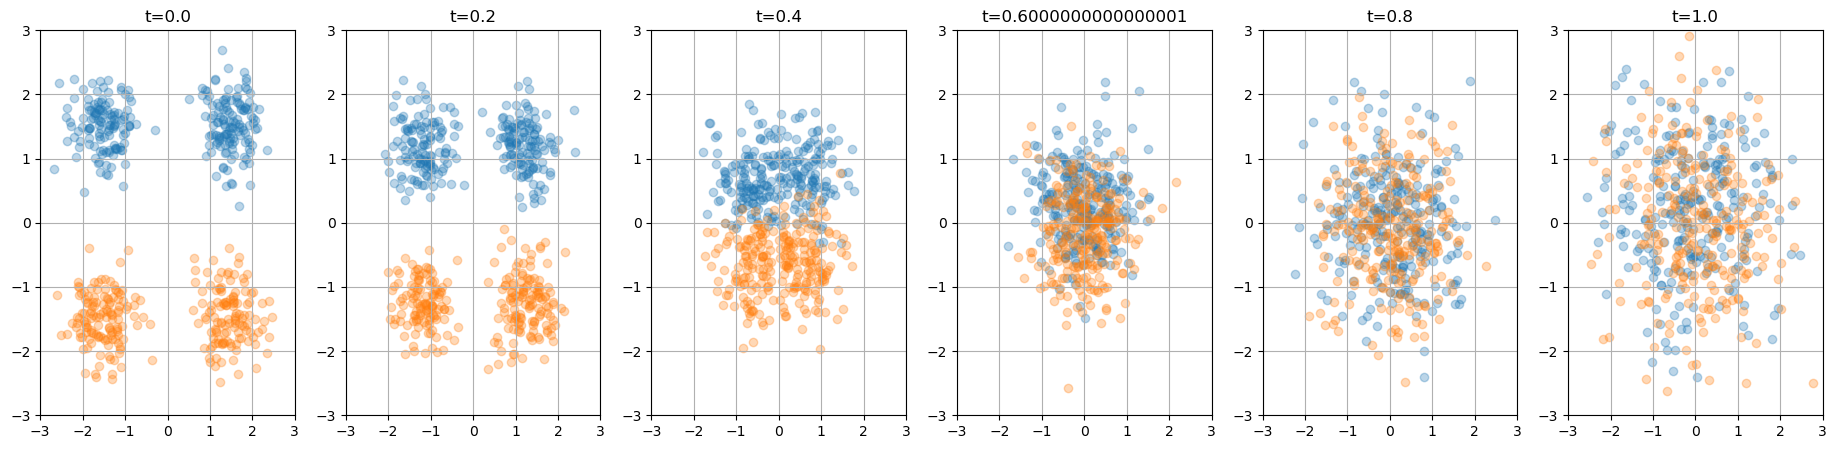

In [4]:
seed = 0
np.random.seed(seed)
key = random.PRNGKey(seed)
bs = 512
t_axis = np.linspace(0.0, 1.0, 6)

plt.figure(figsize=(23,5))
for i in range(len(t_axis)):
  plt.subplot(1,len(t_axis),i+1)
  key, *ikey = random.split(key, 5)
  _, x_t_up = q_t(ikey[1], sample_data(ikey[0], bs//2, up=True), t_axis[i])
  _, x_t_down = q_t(ikey[3], sample_data(ikey[2], bs//2, up=False), t_axis[i])
  plt.scatter(x_t_up[:,0], x_t_up[:,1], alpha=0.3)
  plt.scatter(x_t_down[:,0], x_t_down[:,1], alpha=0.3)
  plt.title(f't={t_axis[i]}')
  plt.xlim(-3,3)
  plt.ylim(-3,3)
  plt.grid()

## Define the Model

In [5]:
class MLP(nn.Module):
  num_hid : int
  num_out : int

  @nn.compact
  def __call__(self, t, x):
    h = jnp.hstack([t,x])
    h = nn.Dense(features=self.num_hid)(h)
    h = nn.swish(h)
    h = nn.Dense(features=self.num_hid)(h)
    # h = nn.swish(h)
    # h = nn.Dense(features=self.num_hid)(h)
    h = nn.swish(h)
    h = nn.Dense(features=self.num_hid)(h)
    h = nn.swish(h)
    h = nn.Dense(features=self.num_out)(h)
    return h

def train_model(key, data_generator):
  model = MLP(num_hid=512, num_out=ndim)
  key, init_key = random.split(key)
  optimizer = optax.adam(learning_rate=2e-4)
  state = train_state.TrainState.create(apply_fn=model.apply,
                                        params=model.init(init_key, np.ones([bs,1]), np.zeros([bs,ndim])),
                                        tx=optimizer)
  
  def sm_loss(state, key, params, bs):
    keys = random.split(key, )
    sdlogqdx = lambda _t, _x: state.apply_fn(params, _t, _x)
    data = data_generator(keys[0], bs)
    t = random.uniform(keys[1], [bs,1])
    eps, x_t = q_t(keys[2], data, t)
    loss = ((eps + sdlogqdx(t, x_t))**2).sum(1)
    return loss.mean()

  @partial(jax.jit, static_argnums=1)
  def train_step(state, bs, key):
    grad_fn = jax.value_and_grad(sm_loss, argnums=2)
    loss, grads = grad_fn(state, key, state.params, bs)
    state = state.apply_gradients(grads=grads)
    return state, loss
  
  num_iterations = 20_000
  key, loop_key = random.split(key)
  for iter in trange(num_iterations):
    state, _ = train_step(state, bs, random.fold_in(loop_key, iter))
  return state

In [6]:
key, ikey = random.split(key)
state_up = train_model(ikey, partial(sample_data, up=True))
key, ikey = random.split(key)
state_down = train_model(ikey, partial(sample_data, up=False))

100%|██████████| 20000/20000 [00:09<00:00, 2172.68it/s]


## Analytic Models for Experiments

We want very simple Gaussian Modes to mirror propositional variables.
We can just define these mixtures of Gaussians analytically.


In [7]:
from typing import Literal
import jax
import jax.numpy as jnp
from flax import linen as nn

# ====== shared math (closed forms) ======

def _a(t):        # mean scale  a(t) = 1 - t
    return 1.0 - t

def _s2(t, sigma):  # variance schedule s^2(t) = (1-t) sigma^2 + t
    return (1.0 - t) * (sigma**2) + t

def _m(t):        # corner magnitude along each axis at time t (== 2 a(t))
    return 4.0 * _a(t)

def _mu_bar_all(x, t, sigma):
    # posterior mean of component for the "all corners" case, elementwise:
    # μ̄_j = 2 a(t) * tanh( [2 a(t) / s^2(t)] * x_j )
    at = _a(t)                   # [bs,1]
    s2t = _s2(t, sigma)          # [bs,1]
    return 2.0 * at * jnp.tanh((2.0 * at / s2t) * x)

def _mu_bar_one_side(x, t, sigma, axis: int = 0):
    at = _a(t)
    s2t = _s2(t, sigma)
    mubar = 2.0 * at * jnp.tanh((2.0 * at / s2t) * x)
    twoa = jnp.squeeze(2.0 * at, axis=-1)           # [bs]
    mubar = mubar.at[..., axis].set(twoa)           # force chosen coord to +2a(t)
    return mubar

def _score(x, t, sigma, which: Literal["all","one_side"], axis: int = 0):
    s2t = _s2(t, sigma)
    mubar = _mu_bar_all(x, t, sigma) if which == "all" else _mu_bar_one_side(x, t, sigma, axis)
    return (mubar - x) / s2t

def _loglik_one_side(x, t, sigma, axis: int = 0):
    s2t = _s2(t, sigma)
    mt  = _m(t)
    # selected (one-sided) coordinate: N(x_axis | +m, s2)
    x_axis = x[..., axis:axis+1]                    # [bs,1]
    ll_axis = -0.5 * jnp.log(2.0 * jnp.pi * s2t) - ((x_axis - mt)**2) / (2.0 * s2t)  # [bs,1]
    # remaining coordinates: symmetric mixtures
    if x.shape[-1] == 1:
        return ll_axis
    x_rest = jnp.concatenate([x[..., :axis], x[..., axis+1:]], axis=-1)  # [bs,k-1]
    xrp = -((x_rest - mt)**2) / (2.0 * s2t)
    xrm = -((x_rest + mt)**2) / (2.0 * s2t)
    per_dim = -0.5 * jnp.log(2.0 * jnp.pi * s2t) + jnp.logaddexp(xrp, xrm) - jnp.log(2.0)
    return ll_axis + jnp.sum(per_dim, axis=-1, keepdims=True)

def _loglik(x, t, sigma, which: Literal["all","one_side"], axis: int = 0):
    return _loglik_all(x, t, sigma) if which == "all" else _loglik_one_side(x, t, sigma, axis)

def _loglik_all(x, t, sigma):
    # log p_t(x) for the "all corners" case, using a stable 1D factorization.
    # per-dim: log[ 0.5 N(x|+m,s2) + 0.5 N(x|-m,s2) ]
    # = -0.5*log(2π s2) + logaddexp( -((x-m)^2)/(2s2), -((x+m)^2)/(2s2) ) - log 2
    s2t = _s2(t, sigma)                          # [bs,1]
    mt  = _m(t)                                  # [bs,1]
    xmp = - ( (x - mt)**2 ) / (2.0 * s2t)
    xmm = - ( (x + mt)**2 ) / (2.0 * s2t)
    per_dim = -0.5 * jnp.log(2.0 * jnp.pi * s2t) + jnp.logaddexp(xmp, xmm) - jnp.log(2.0)
    return jnp.sum(per_dim, axis=-1, keepdims=True)  # [bs,1]

# ====== plug-and-play modules ======

class HardcodedScore(nn.Module):
    """Drop-in replacement for MLP that outputs the score ∇_x log p_t(x)."""
    num_out: int
    sigma: float
    which: Literal["all","one_side"] = "all"
    axis: int = 0
    sign: Literal[-1, 1] = 1

    @nn.compact
    def __call__(self, t, x):
        # t: [bs,1], x: [bs,ndim]
        score = _score(x*self.sign, t, self.sigma, self.which, self.axis)*self.sign   # [bs, ndim]
        # sanity: make sure user-set num_out matches ndim
        assert score.shape[-1] == self.num_out, f"num_out={self.num_out} but x has ndim={score.shape[-1]}"
        return score
    
    @nn.compact
    def likelihood(self, t, x):
        # t: [bs,1], x: [bs,ndim]
        ll = _loglik(x*self.sign, t, self.sigma, self.which,self.axis)     # [bs,1]
        return ll

class HardcodedLogLik(nn.Module):
    """Same interface, but returns log p_t(x) in shape [bs,1]."""
    sigma: float
    which: Literal["all","one_side"] = "all"

    @nn.compact
    def __call__(self, t, x):
        ll = _loglik(x, t, self.sigma, self.which)     # [bs,1]
        assert self.num_out == 1, f"Set num_out=1 for log-likelihood; got {self.num_out}"
        return ll


## Define SAT instances and their models

In [8]:
# TODO define list of ndim/instance pairs
import itertools
def majority_dimacs(ndim: int, k: int = None):
    if k is None:
        k = ndim // 2 + 1
    return [[c + 1 for c in comb] for comb in itertools.combinations(range(ndim), k)]
    
def exactly_k_dimacs(ndim: int, k: int):
    return [[c + 1 if c in comb else -c-1 for c in range(ndim)] for comb in itertools.combinations(range(ndim), k)]
    
def xor_dimacs(ndim: int):
    """
    xor is a parity function: we proceed similar to the majority
    """
    return [i for k in range(ndim // 2 + (ndim % 2)) for i in exactly_k_dimacs(ndim,2*k+1)]
    
def exactly_one_dimacs(ndim: int):
    # CNF: (x1 ∨ ... ∨ xn) ∧ ∧_{i<j}(¬xi ∨ ¬xj)
    return [[i + 1 for i in range(ndim)]] + [[-(i + 1), -(j + 1)]
                                             for i in range(ndim)
                                             for j in range(i + 1, ndim)]

import itertools

def xor_dimacs(n):
    clauses = []
    for bits in itertools.product([0,1], repeat=n):
        if sum(bits) % 2 == 0:   # forbid even parity
            clause = [-(i+1) if bits[i] else (i+1) for i in range(n)]
            clauses.append(clause)
    return clauses




# TODO define checkers and reporting
# maj_instances  = [(n, majority_dimacs(n)) for n in range(2, 11)]
# xor_instances  = [(n, xor_dimacs(n)) for n in range(2, 11)]

# print(xor_dimacs(4))


In [9]:
from flax.nnx import TrainState


# TODO define models and model parameters

def propositional_Gausses(ndim, sigma = .5, key = key) -> (TrainState,[TrainState]): 
    model = HardcodedScore(num_out=ndim, sigma=sigma/1.5, which="all",axis=0)
    key, init_key = random.split(key)
    optimizer = optax.adam(learning_rate=2e-4)
    state = train_state.TrainState.create(apply_fn=model.apply,
                                        params=model.init(init_key, np.ones([bs,1]), np.zeros([bs,ndim])),
                                        tx=optimizer)
    base_model = state
    dim_models = []
    for i in range(ndim):
        model = HardcodedScore(num_out=ndim, sigma=sigma, which="one_side",axis=i, sign=1)
        key, init_key = random.split(key)
        optimizer = optax.adam(learning_rate=2e-4)
        state = train_state.TrainState.create(apply_fn=model.apply,
                                              params=model.init(init_key, np.ones([bs,1]), np.zeros([bs,ndim])),
                                              tx=optimizer)
        dim_models.append(state)
    return base_model, dim_models


In [10]:
# TODO helpers
@jax.jit
def get_stoch_dll(t,dt,x,dx,sscore):
  output = ndim*dt*dlog_alphadt(t) - dt*beta(t)*(sscore**2)/jnp.exp(log_sigma(t))
  output += ((dx + dt*dlog_alphadt(t)*x)*sscore/jnp.exp(log_sigma(t)))
  return output.sum(1)

def get_dx(x_t):
    dx = -dt*(dlog_alphadt(t)*x_t - 2*beta(t)*scores)
    dx += jnp.sqrt(2*jnp.exp(log_sigma(t))*beta(t)*dt)*random.normal(ikey, shape=(bs,2))
    

# Run SAT experiment and generate CSV result file

In [11]:
from pathlib import Path
%load_ext autoreload
%autoreload 2
import sys
import os
sys.path.append(os.path.abspath(".."))
from sat.score_composer import compose_formula_with_reference
from sat.propositional_diffusion_models import get_ll
from sat.fuzzy_checker import analyze_sampler_sparse

# %skip


# TODO define simulation parameters

bs = 1024 #number of particles
dt = 1e-2 #delta t
t_init = 1.0 #initial t
n = int(t_init / dt) #number timesteps

lamb = 10 #lambda
ndim = 5
sigma = .5

out = ""#Path("sat_results_100_steps_fixed_xor.csv")
# with out as f:#out.open("a", encoding="utf-8") as f:
    # optional header on first write
    # if f.tell() == 0:
print("method;lambda;instance;d;n_points;n_corr;n_outside;n_wrong;perplexity;num_modes;max_count;frac_corr_all;frac_corr_within")#,
          #file=f)

for ndim in [2]:#,5,10,1,3,4,6,7,8,9]:
    for name,instance in [("majority",majority_dimacs(ndim)),
                          ("xor",xor_dimacs(ndim)),
                          ("exactly_one",exactly_one_dimacs(ndim))]:
        for method in ["dombi", "prob"]:
            for lamb in [0.5,1,5,10,100]:
                if method == "prob" and not lamb == 1:
                    continue
                t = t_init * jnp.ones((bs, 1))
                key, ikey = random.split(key, num=2)
                # particle traces over time
                
                x_gen = jnp.zeros((bs, n + 1, ndim))
                ll_gen = jnp.zeros((bs, n + 1, ndim + 1))
                x_gen = x_gen.at[:, 0, :].set(random.normal(ikey, shape=(bs, ndim)))
                
                base, dim_models = propositional_Gausses(ndim, sigma = sigma)
                
                for i in range(n):
                    x_t = x_gen[:, i, :]
                    key, ikey = random.split(key, num=2)
                    scores, _ = compose_formula_with_reference(dim_models, t, x_t, instance, base, ell=lamb, method=method)
                    
                    dx = -dt * (dlog_alphadt(t) * x_t - 2 * beta(t) * scores)
                    dx += jnp.sqrt(2 * jnp.exp(log_sigma(t)) * beta(t) * dt) * random.normal(ikey, shape=(bs, ndim))
                    x_gen = x_gen.at[:, i + 1, :].set(x_t + dx)
                
                    t -= dt
                    
                x = analyze_sampler_sparse(x_gen[:, -1, :], instance, 2, .75, metric="linf")
    
                anycorr = x.correct_modes_uniformity
                print(method,
                      lamb,
                      name,
                      x.d,
                      x.n_points,
                      x.correct_modes_uniformity.n if anycorr else 0,
                      x.n_points-x.n_within_sigma,
                      x.n_within_sigma-x.correct_modes_uniformity.n if anycorr else 0,
                      x.correct_modes_uniformity.perplexity if anycorr else 0,
                      x.correct_modes_uniformity.K if anycorr else 0,
                      max(x.correct_modes_uniformity.counts) if anycorr else 0,
                      x.correct_modes_uniformity.n/x.n_points if anycorr else 0,
                      x.correct_modes_uniformity.n/x.n_within_sigma if anycorr else 0, sep=";")#,#file=f,flush=True)

d=4, N=1000, metric=l2, σ=0.5, float32=True
Within σ: 1000 (1.000)
Occupied bins: 4 (collisions: 996)
Uniformity over OCCUPIED bins:
  expected per bin: 250.000 (K_occ=4)
  χ²=0.000, p=1
  TV=0.0000, L∞=0.0000, H=2.000 bits (100.0% of max), perplexity=4.00
Uniformity over OCCUPIED & CORRECT bins (K=3):
  χ²=0.000, p=1
  TV=0.0000, L∞=0.0000, H=1.585 bits, perplexity=3.00
method;lambda;instance;d;n_points;n_corr;n_outside;n_wrong;perplexity;num_modes;max_count;frac_corr_all;frac_corr_within
dombi;0.5;majority;2;1024;1023;1;0;2.1110863721336437;3;760;0.9990234375;1.0
dombi;1;majority;2;1024;1024;0;0;2.501155123421263;3;644;1.0;1.0
dombi;5;majority;2;1024;1024;0;0;2.9674139507015784;3;413;1.0;1.0
dombi;10;majority;2;1024;1024;0;0;2.9806430049009234;3;389;1.0;1.0
dombi;100;majority;2;1024;1024;0;0;2.9878845352040484;3;369;1.0;1.0
prob;1;majority;2;1024;1020;4;0;2.43575774916365;3;662;0.99609375;1.0
dombi;0.5;xor;2;1024;839;0;185;1.9940009026893004;2;452;0.8193359375;0.8193359375
dombi;1;xo

## Experiment Visualisation

### Simulation

In [12]:
bs = 128 #number of particles
dt = 1e-2 #delta t
t_init = 1.0 #initial t
n = int(t_init / dt) #number timesteps

lamb = 10 #lambda
ndim = 2
sigma = .5

instance = majority_dimacs(ndim)
points = {}
for name, instance in [("majority",majority_dimacs(ndim)),
                      ("one",exactly_one_dimacs(ndim)),
                      ("xor",xor_dimacs(ndim))]:
    for method in ["dombi", "prob"]:
        t = t_init * jnp.ones((bs, 1))
        key, ikey = random.split(key, num=2)
        # particle traces over time
        
        x_gen = jnp.zeros((bs, n + 1, ndim))
        ll_gen = jnp.zeros((bs, n + 1, ndim + 1))
        x_gen = x_gen.at[:, 0, :].set(random.normal(ikey, shape=(bs, ndim)))
        
        base, dim_models = propositional_Gausses(ndim, sigma = sigma)
        
        for i in range(n):
            x_t = x_gen[:, i, :]
            key, ikey = random.split(key, num=2)
            scores, _ = compose_formula_with_reference(dim_models, t, x_t, instance, base, ell=lamb, method=method)
            
            dx = -dt * (dlog_alphadt(t) * x_t - 2 * beta(t) * scores)
            dx += jnp.sqrt(2 * jnp.exp(log_sigma(t)) * beta(t) * dt) * random.normal(ikey, shape=(bs, ndim))
            x_gen = x_gen.at[:, i + 1, :].set(x_t + dx)
            
            t -= dt
        points[name,method] = x_gen[:, i+1, :]
                        

### Plotting

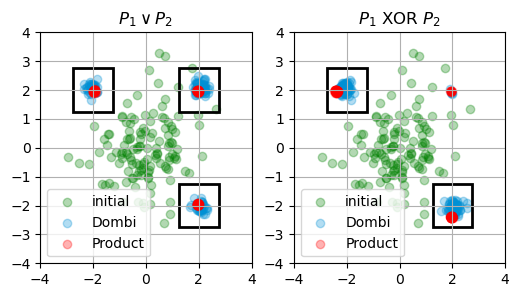

[[1, 2], [-1, -2]]


In [13]:
from matplotlib import patches

plt.figure(figsize=(6, 3))

plt.subplot(1,2,1)
plt.grid()
plt.scatter(x_gen[:,0,0], x_gen[:,0,1], label='initial', alpha=.3, color="green")
plt.scatter(points["majority","dombi"][:,0], points["majority","dombi"][:,1], label='Dombi', alpha=.3, color="#0090D4")
plt.scatter(points["majority","prob"][:,0], points["majority","prob"][:,1], label='Product', alpha=.3, color="red")
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.title("$P_1 \\vee P_2$")
plt.legend()
rect = patches.Rectangle((2-0.75, 2-0.75), 1.5, 1.5,
                         linewidth=2, edgecolor='black', facecolor='none')
plt.gca().add_patch(rect)
rect = patches.Rectangle((2-0.75, -2-0.75), 1.5, 1.5,
                         linewidth=2, edgecolor='black', facecolor='none')
plt.gca().add_patch(rect)
rect = patches.Rectangle((-2-0.75, 2-0.75), 1.5, 1.5,
                         linewidth=2, edgecolor='black', facecolor='none')
plt.gca().add_patch(rect)


plt.subplot(1,2,2)
plt.grid()
plt.scatter(x_gen[:,0,0], x_gen[:,0,1], label='initial', alpha=.3, color="green")
plt.scatter(points["xor","dombi"][:,0], points["xor","dombi"][:,1], label='Dombi', alpha=.3, color="#0090D4")
plt.scatter(points["xor","prob"][:,0], points["xor","prob"][:,1], label='Product', alpha=.3, color="red")
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.legend()
plt.title("$P_1 \\text{ XOR } P_2$")

rect = patches.Rectangle((2-0.75, -2-0.75), 1.5, 1.5,
                         linewidth=2, edgecolor='black', facecolor='none')
plt.gca().add_patch(rect)
rect = patches.Rectangle((-2-0.75, 2-0.75), 1.5, 1.5,
                         linewidth=2, edgecolor='black', facecolor='none')
plt.gca().add_patch(rect)

# plt.savefig("R2_formulas.pdf", bbox_inches='tight', pad_inches=0)
plt.show()
print(xor_dimacs(2))



## Render Table

In [14]:
import csv
from collections import defaultdict

# read CSV
rows = []
with open("sat_results_combined.csv") as f:
    reader = csv.DictReader(f, delimiter=";")
    for row in reader:
        row["d"] = int(row["d"])
        row["n_points"] = int(row["n_points"])
        row["n_outside"] = int(row["n_outside"])
        row["frac_corr_within"] = float(row["frac_corr_within"])
        row["perplexity"] = float(row["perplexity"])
        row["method"] = row["method"].lower()
        rows.append(row)

# target setup
dims = [2, 5, 10]
methods = {"prob": "Prod", "dombi": "Dombi"}
formulas = [("$\\text{Maj}_k$","majority"), ("$\\text{XOR}_k$","xor"), ("$\\text{OneHot}_k$","exactly_one")]

# collect data: {formula: {method: {d: (corr_within, one_minus_outside, perplexity)}}}
table_data = defaultdict(lambda: defaultdict(dict))
for r in rows:
    if r["d"] not in dims:
        continue
    if r["method"] == "dombi" and float(r["lambda"]) != 100:
        continue
    if r["method"] == "prob" and float(r["lambda"]) != 1:
        continue

    corr_within = r["frac_corr_within"]
    one_minus_outside = 1 - (r["n_outside"] / r["n_points"])
    perplexity = r["perplexity"]

    table_data[r["instance"]][methods[r["method"]]][r["d"]] = (
        corr_within, one_minus_outside, perplexity
    )

# --- Generate LaTeX ---
print("\\begin{table*}[h]")
print("\\centering")
print("\\begin{tabular}{cc"+"".join(["ccc" for _ in dims]) + "}")
print("\\toprule")

# header row
print("&&" + "&".join([f"\\multicolumn{{3}}{{c}}{{Dim {d}}}" for d in dims]) + " \\\\")
print("" + "".join([f"\\cmidrule(l{{3pt}}r{{3pt}}){{{col*3+3}-{col*3+5}}}" for col,_ in enumerate(dims)]) + " \\\\")
print("Formula&Method&" + "&".join(["SAT&Surv&P" for _ in dims]) + " \\\\")
print("\\midrule")

# body
for name, formula in formulas:
    methods_here = list(table_data[formula].keys())
    if not methods_here:
        continue
    print(f"\\multirow{{{len(methods_here)}}}{{*}}{{{name}}}", end=" ")
    for i, method in enumerate(methods_here):
        if i > 0:
            print(" &", end=" ")
        else:
            print("&", end=" ")
        print(method, end=" ")
        for d in dims:
            vals = table_data[formula][method].get(d, ("-", "-", "-"))
            if isinstance(vals[0], float):
                print(f"&{vals[0]:.2f}&{vals[1]:.2f}&{vals[2]:.2f}", end=" ")
            else:
                print("& - & - & -", end=" ")
        print("\\\\")
    print("\\midrule")

print("\\bottomrule")
print("\\end{tabular}")
print("\\caption{Comparison of Dombi vs Product across selected dimensions.}")
print("\\end{table*}")



FileNotFoundError: [Errno 2] No such file or directory: 'sat_results_combined.csv'

# With FKC

In [ ]:
from sat.propositional_diffusion_models import get_sscore
from library.feynman_kac_correction.fkc_power_norms import fkc_power_norm, \
    fkc_referenced_cnf_composition
from library.feynman_kac_correction.fkc_by_terms import fkc_annealing_full_pde
from library.feynman_kac_corrector import resample_cat_systematic


def log_prob_std_normal(x):
    """
    Log-likelihood under isotropic N(0, I) for a batch of particles.
    x: (batch_size, ndim)
    """
    d = x.shape[-1]
    return -0.5 * (jnp.sum(x**2, axis=-1) + d * jnp.log(2 * jnp.pi))

bs = 2048 #number of particles
dt = 1e-2 #delta t
t_init = 1.0 #initial t
n = int(t_init / dt) #number timesteps
resample = True
lamb = 5 #lambda
ndim = 5
sigma = .5

# def majority_dimacs(d):
#     return [[1,2]]
# xor_dimacs = exactly_one_dimacs = majority_dimacs


instance = majority_dimacs(ndim)
points = {}
for ndim in [10,3,4,5,6,7,8,9,10,15]:
    for name, instance in [("one",exactly_one_dimacs(ndim)),
                           ("xor",xor_dimacs(ndim)),
                          ("majority",majority_dimacs(ndim))]:
        for method in ["dombi", "prob"]:
            t = t_init * jnp.ones((bs, 1))
            key, ikey = random.split(key, num=2)
            # particle traces over time
            # 
            x_gen = jnp.zeros((bs, n + 1, ndim))
            ll_gen = jnp.zeros((bs, n + 1))
            w_gen = jnp.zeros((bs, n + 1))
            x_gen = x_gen.at[:, 0, :].set(random.normal(ikey, shape=(bs, ndim)))
            
            base, dim_models = propositional_Gausses(ndim, sigma = sigma)
            
            for i in range(n):
                x_t = x_gen[:, i, :]
                key, ikey = random.split(key, num=2)
                big_score, big_lls = compose_formula_with_reference(dim_models, t, x_t, instance, base, ell=lamb, method=method)
                
                # model
                # TODO!!
                scores = [get_sscore(model, t, x_t) for model in dim_models]
                lls = [get_ll(model, t, x_t) for model in dim_models]
                      
                div_f = dlog_alphadt(t)*ndim # divergence of the drift field
                g = jnp.sqrt(2/jnp.exp(log_sigma(t))*beta(t)) # diffusion coefficient
                
                score, ll, weight = fkc_referenced_cnf_composition(
                    [score*g for score in scores],
                    lls,
                    get_sscore(base,t,x_t)*g,
                    get_ll(base,t,x_t),
                    # 1/jnp.exp(log_sigma(t))*g
                    div_f,
                    instance,
                    lamb
                )
                # print(big_lls - ll)
                # score*jnp.exp(log_sigma(t))/g
                # print(score*jnp.exp(log_sigma(t))/g-big_score)
    
                
                dx = -dt * (dlog_alphadt(t) * x_t - 2 * beta(t) * score/g)
                dx += jnp.sqrt(2 * jnp.exp(log_sigma(t)) * beta(t) * dt) * random.normal(ikey, shape=(bs, ndim))
    
                # print(dw.shape)
                w_gen = w_gen.at[:,i+1].set(w_gen[:,i] + dt*weight)
                # print(jnp.min(dt*weight[:,None]))
                if resample and .10 < t[0] < .3:
                    key, ikey = random.split(key, num=2)
                    new_ids = resample_cat_systematic(bs, ikey, w_gen[:,i+1])
                    x_gen = x_gen.at[:,i+1].set(x_gen[new_ids,i+1,:])
                w_gen = w_gen.at[:,i+1].set(0)
                t -= dt
            break
        break
    break
        # points[ndim, name, method] = x_gen[:, i+1, :]

: 

## Check

In [ ]:
##TODO: WEIRD BEHAVIOR: MODE COLLAPSE *PRECISELY* AT .5
## WHY???

x = analyze_sampler_sparse(x_gen[:, i+1, :], instance, 2, 1.0, metric="linf")
    
anycorr = x.correct_modes_uniformity
print(method,
      lamb,
      name,
      x.d,
      x.n_points,
      x.correct_modes_uniformity.n if anycorr else 0,
      x.n_points-x.n_within_sigma,
      x.n_within_sigma-x.correct_modes_uniformity.n if anycorr else 0,
      "perplexity:",
      x.correct_modes_uniformity.perplexity if anycorr else 0,
      x.correct_modes_uniformity.K if anycorr else 0,
      max(x.correct_modes_uniformity.counts) if anycorr else 0,
      x.correct_modes_uniformity.n/x.n_points if anycorr else 0,
      x.correct_modes_uniformity.n/x.n_within_sigma if anycorr else 0, sep=";")

dombi;100;one;10;2048;175;0;1873;perplexity:;9.62919970408872;10;31;0.08544921875;0.08544921875


In [ ]:
print(x_gen[:,n,:].mean(axis=0))

[-1.6025376  -1.3053331  -0.36214763 -1.7051958  -1.1308451 ]


## FKC Correctness Tests

In [ ]:
%load_ext autoreload
%autoreload 2

# import jax.numpy as jnp

def log_prob_std_normal(x):
    """
    Log-likelihood under isotropic N(0, I) for a batch of particles.
    x: (batch_size, ndim)
    """
    d = x.shape[-1]
    return -0.5 * (jnp.sum(x**2, axis=-1) + d * jnp.log(2 * jnp.pi))


from sat.propositional_diffusion_models import get_sscore
from library.feynman_kac_correction.fkc_power_norms import fkc_power_norm, fkc_power_norm_bk, \
    fkc_referenced_cnf_composition
from library.feynman_kac_correction.fkc_by_terms import fkc_annealing_full_pde,fkc_mixture_full_pde, fkc_cfg_full_pde
from library.feynman_kac_corrector import resample_cat_systematic

bs = 2048 #number of particles
dt = 1e-2 #delta t
t_init = 1.0 #initial t
n = int(t_init / dt) #number timesteps
resample = True

ndim = 2
sigma = .5
t = t_init * jnp.ones((bs, 1))
key, ikey = random.split(key, num=2)
# particle traces over time
# 
x_gen = jnp.zeros((bs, n + 1, ndim))
ll_gen = jnp.zeros((bs, n + 1, 1))
w_gen = jnp.zeros((bs, n + 1, 1))
x_gen = x_gen.at[:, 0, :].set(random.normal(ikey, shape=(bs, ndim)))
ll_gen = ll_gen.at[:,0,0].set(log_prob_std_normal(x_gen[:,0,:]))

base, dim_models = propositional_Gausses(ndim, sigma = sigma)
# instance = [[1,2]];lamb = 1 # 1 or 2, at lambda = 1 is just mixture ####WORKS
# instance = [[-2]];lamb = 1 # -2 referenced by 1 should give CFG #####WORKS
instance = [[1,-2]];lamb = 1 # 1 plus -2 ref by 1 should give Contrast with FKC ### INCONCLUSIVE??


for i in range(n):
    x_t = x_gen[:, i, :]
    key, ikey = random.split(key, num=2)
    big_score, big_lls = compose_formula_with_reference(dim_models, t, x_t, instance, base, ell=lamb, method=method)
    
    # model
    # TODO!!
    scores = [get_sscore(model, t, x_t) for model in dim_models]
    lls = [get_ll(model, t, x_t) for model in dim_models]
    # assert not jnp.isnan(lls[1]).any()
    div_f = dlog_alphadt(t)*ndim # divergence of the drift field
    g = jnp.sqrt(2/jnp.exp(log_sigma(t))*beta(t)) # diffusion coefficient
    
    score, ll, weight = fkc_referenced_cnf_composition(
        [score*g for score in scores],
        lls,
        get_sscore(base, t, x_t)*g,
        get_ll(base, t, x_t),
        # 1/jnp.exp(log_sigma(t))*g
        div_f,
        instance,
        lamb
    )
    assert not jnp.isnan(score).any(), "Score math fail"
    assert not jnp.isnan(ll).any()
    assert not jnp.isnan(weight).any()
    
    # mixture_weight = fkc_mixture_full_pde([jnp.zeros_like(score*g) for score in scores], lls)
    # print((mixture_weight-weight).sum())

    cfg_weight = fkc_cfg_full_pde([score*g for score in scores],2)
    print(cfg_weight.sum(), weight.sum(), (cfg_weight - weight).sum())

    #print(big_lls - ll)
    # score*jnp.exp(log_sigma(t))/g
    # print(score*jnp.exp(log_sigma(t))/g-big_score)

    
    dx = -dt * (dlog_alphadt(t) * x_t - 2 * beta(t) * score/g)
    dx += jnp.sqrt(2 * jnp.exp(log_sigma(t)) * beta(t) * dt) * random.normal(ikey, shape=(bs, ndim))
    x_gen = x_gen.at[:, i + 1, :].set(x_t + dx)
    # print(dw.shape)
    w_gen = w_gen.at[:,i+1,:].set(w_gen[:,i,:] + dt*weight*.35)
    # print(jnp.min(dt*weight[:,None]))
    if resample:
        key, ikey = random.split(key, num=2)
        new_ids = resample_cat_systematic(bs, ikey, w_gen[:,i+1,0])
        x_gen = x_gen.at[:,i+1,:].set(x_gen[new_ids,i+1,:])
        w_gen = w_gen.at[:,i+1,:].set(0)
    t -= dt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
0.0 0.0 0.0
272.8324 96.58468 176.24774
548.1752 194.09631 354.0789
826.1316 292.88766 533.2439
1106.2455 393.0899 713.1556
1388.9685 494.98975 893.9787
1671.9885 597.9185 1074.0701
1961.2498 704.6816 1256.5682
2256.729 816.62366 1440.1055
2553.7856 930.29663 1623.4889
2855.5208 1049.8488 1805.6719
3159.1123 1172.8572 1986.2552
3471.953 1300.6858 2171.267
3772.3752 1425.2463 2347.1292
4083.3975 1554.337 2529.0605
4406.2964 1702.0815 2704.2146
4776.2676 1892.0736 2884.1943
5136.8594 2083.1208 3053.738
5475.373 2256.126 3219.2466
5837.786 2458.4033 3379.3828
6220.5796 2690.3535 3530.2263
6595.1826 2924.2769 3670.9058
6993.4688 3175.5352 3817.9336
7408.3203 3436.2886 3972.0317
7871.8193 3773.2412 4098.578
8310.174 4086.8818 4223.293
8817.292 4481.4756 4335.8164
9292.0625 4859.8613 4432.2
9775.339 5278.6196 4496.7197
10306.943 5735.4023 4571.541
10881.551 6258.198 4623.3535
11432.026 6754.494 4677.532
1

## Visualisation

KeyError: ('majority', 'dombi')

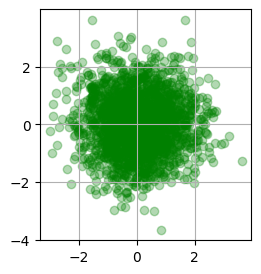

In [ ]:
from matplotlib import patches

plt.figure(figsize=(6, 3))

plt.subplot(1,2,1)
plt.grid()
plt.scatter(x_gen[:,0,0], x_gen[:,0,1], label='initial', alpha=.3, color="green")
plt.scatter(points["majority","dombi"][:,0], points["majority","dombi"][:,1], label='Dombi', alpha=.3, color="#0090D4")
plt.scatter(points["majority","prob"][:,0], points["majority","prob"][:,1], label='Product', alpha=.3, color="red")
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.title("$P_1 \\vee P_2$")
plt.legend()
rect = patches.Rectangle((2-0.75, 2-0.75), 1.5, 1.5,
                         linewidth=2, edgecolor='black', facecolor='none')
plt.gca().add_patch(rect)
rect = patches.Rectangle((2-0.75, -2-0.75), 1.5, 1.5,
                         linewidth=2, edgecolor='black', facecolor='none')
plt.gca().add_patch(rect)
rect = patches.Rectangle((-2-0.75, 2-0.75), 1.5, 1.5,
                         linewidth=2, edgecolor='black', facecolor='none')
plt.gca().add_patch(rect)


plt.subplot(1,2,2)
plt.grid()
plt.scatter(x_gen[:,0,0], x_gen[:,0,1], label='initial', alpha=.3, color="green")
plt.scatter(points["xor","dombi"][:,0], points["xor","dombi"][:,1], label='Dombi', alpha=.3, color="#0090D4")
plt.scatter(points["xor","prob"][:,0], points["xor","prob"][:,1], label='Product', alpha=.3, color="red")
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.legend()
plt.title("$P_1 \\text{ XOR } P_2$")

rect = patches.Rectangle((2-0.75, -2-0.75), 1.5, 1.5,
                         linewidth=2, edgecolor='black', facecolor='none')
plt.gca().add_patch(rect)
rect = patches.Rectangle((-2-0.75, 2-0.75), 1.5, 1.5,
                         linewidth=2, edgecolor='black', facecolor='none')
plt.gca().add_patch(rect)

# plt.savefig("R2_formulas.pdf", bbox_inches='tight', pad_inches=0)
plt.show()
print(xor_dimacs(2))



## Random stuff

In [ ]:
print(instance)

anycorr = x.correct_modes_uniformity
# print(x_t)
print(
    x.d,
      x.n_points,
      x.correct_modes_uniformity.n if anycorr else 0,
      x.n_points-x.n_within_sigma,
      x.n_within_sigma-x.correct_modes_uniformity.n if anycorr else 0,
      x.correct_modes_uniformity.perplexity if anycorr else 0,
      x.correct_modes_uniformity.K if anycorr else 0,
      max(x.correct_modes_uniformity.counts) if anycorr else 0,
      x.correct_modes_uniformity.n/x.n_points if anycorr else 0)
# print(instance)

[[1, 2], [-1, -2]]


NameError: name 'x' is not defined

In [ ]:
from sat.fuzzy_checker import analyze_sampler_sparse

x = analyze_sampler_sparse(x_gen[:, -1, :], instance, 2, .75, metric="linf")
print(x)
print(
    f'\n\n\n{x.correct_modes_uniformity.n} correct and {x.all_modes_uniformity.n - x.correct_modes_uniformity.n} incorrect :(\nCorrect mode perplexity is {x.correct_modes_uniformity.perplexity}')

## Create an Analytic Model

In [ ]:
from sat.propositional_diffusion_models import HardcodedScore
from sat.parse import parse_dimacs_cnf
clauses = [
    [1, 2, 3],
    [1, -2, -3],
    [-1, 2, -3],
    [-1, -2, 3],
    [-2, -3, -4],
    [-2, 3, 4],
    [2, -3, 4],
    [2, 3, -4],
    [4, 5, 6],
    [4, -5, -6],
    [-4, 5, -6],
    [-4, -5, 6],
    [-6, -7, -8],
    [-6, 7, 8],
    [6, -7, 8],
    [6, 7, -8],
    [8, 9, 10],
    [8, -9, -10],
    [-8, 9, -10],
    [-8, -9, 10],
    [-10, -11, -12],
    [-10, 11, 12],
    [10, -11, 12],
    [10, 11, -12],
    [12, 13, 14],
    [12, -13, -14],
    [-12, 13, -14],
    [-12, -13, 14],
    [-1, -5, -9],
    [-1, 5, 9],
    [1, -5, 9],
    [1, 5, -9],
    [2, 7, 11],
    [2, -7, -11],
    [-2, 7, -11],
    [-2, -7, 11],
    [-1],
    [-2]
] # 8 models out of 2**14 ~= 16k

# ndim, instance = parse_dimacs_cnf("../sat_instances/uf20-07.cnf")
# ndim, instance = 5, [[1,-2],[-1,2],[1,-3],[-1,3],[2,-3],[-2,3],[-4,5]]
ndim, instance = 3, [[i for i in range(1,4)]]
# ndim, instance = 2, [[1,-2],[-1,2]]
# ndim, instance = 14, clauses
model = HardcodedScore(num_out=ndim, sigma=.5, which="all",axis=0)
key, init_key = random.split(key)
optimizer = optax.adam(learning_rate=2e-4)
state = train_state.TrainState.create(apply_fn=model.apply,
                                    params=model.init(init_key, np.ones([bs,1]), np.zeros([bs,ndim])),
                                    tx=optimizer)
base_model = state
dim_models = []
for i in range(ndim):
    states = {}
    for sign in [1,-1]:
        model = HardcodedScore(num_out=ndim, sigma=.5, which="one_side",axis=i, sign=sign)
        key, init_key = random.split(key)
        optimizer = optax.adam(learning_rate=2e-4)
        state = train_state.TrainState.create(apply_fn=model.apply,
                                            params=model.init(init_key, np.ones([bs,1]), np.zeros([bs,ndim])),
                                            tx=optimizer)
        states[sign] = state
    dim_models.append(states)
print(3)

## Stochastic Superposition and Dombi Composition

In [ ]:
%load_ext autoreload
%autoreload 2
from sat.score_composer import compose_formula, compose_formula_reference

bs = 1024*4

dt = 1e-2
t = 1.0
n = int(t / dt)
t = t * jnp.ones((bs, 1))
key, ikey = random.split(key, num=2)
x_gen = jnp.zeros((bs, n + 1, ndim))
x_gen = x_gen.at[:, 0, :].set(random.normal(ikey, shape=(bs, ndim)))
for i in trange(n):
  x_t = x_gen[:, i, :]
  
  key, ikey = random.split(key, num=2)
  sharpness = 100
  # print(dim_models[0][1])
  scores, _ = compose_formula_reference(dim_models, t, x_t,instance, base_model,ell=sharpness)

  dx = -dt * (dlog_alphadt(t) * x_t - 2 * beta(t) * scores)
  # print(x_t.shape,dx.shape)
  dx += jnp.sqrt(2 * jnp.exp(log_sigma(t)) * beta(t) * dt) * random.normal(ikey, shape=(bs, ndim))
  x_gen = x_gen.at[:, i + 1, :].set(x_t + dx)
  # print(jnp.mean(_ll_1,axis=0),jnp.mean(_ll_2,axis=0),jnp.mean(ll_or,axis=0),jnp.mean(ll_and,axis=0),jnp.mean(ll_all,axis=0),jnp.mean(_ll_base,axis=0))
  t += -dt

x_gen_or = jnp.copy(x_gen)
print((jnp.sign(x_gen[:, -1][:,0]) == jnp.sign(x_gen[:, -1][:,1])).sum() / 512)
plt.figure(figsize=(11.5, 10))
for i in range(len(t_axis)):
  plt.subplot(2, len(t_axis)//2, i + 1)
  key, *ikey = random.split(key, 3)
  t = t_axis[len(t_axis) - 1 - i]
  # _, x_t = q_t(ikey[1], sample_data(ikey[0], bs // 2, up=True), t)
  # plt.scatter(x_t[:, 0], x_t[:, 1], label='noise_data_up', alpha=0.3)
  # _, x_t = q_t(ikey[1], sample_data(ikey[0], bs // 2, up=False) @ jnp.array([[0, -1], [1, 0]]), t)
  # plt.scatter(x_t[:, 0], x_t[:, 1], label='noise_data_down', alpha=0.3)
  plt.scatter(x_gen[:, int(n * (t_axis[i])), 0], x_gen[:, int(n * (t_axis[i])), 1], label='gen_data', alpha=.3, color="orange")
  plt.title(f't={t}')
  plt.xlim(-6, 6)
  plt.ylim(-6, 6)
  plt.grid()
  if i == 0:
    plt.legend(fontsize=15)
  plt.savefig("actual_xor.svg", bbox_inches="tight")

In [ ]:
from sat.fuzzy_checker import analyze_sampler_sparse
x = analyze_sampler_sparse(x_gen[:,int(n * (t_axis[i])),:], instance, 2, .75, metric="linf")
print(x)
print(f'\n\n\n{x.correct_modes_uniformity.n} correct and {x.all_modes_uniformity.n- x.correct_modes_uniformity.n} incorrect :(\nCorrect mode perplexity is {x.correct_modes_uniformity.perplexity}')